# Graph Data Exploration

This notebook explores the structure of a single `Data` object (PyG graph) produced by `preprocess.py`.

## What is each graph?

Each graph represents **one user session with one masked activity node**. The model's task is to predict which activity was masked (`y_act`), and at inference time the prediction confidence is used to detect insider threats (`y_label`).

### Explicit vs Implicit graph (from the paper)

| Graph type | Created when | Stored in `.pt`? | Edges |
|------------|-------------|------------------|-------|
| **Explicit** | Preprocessing | Yes | Sequential (temporal) + Activity-type cliques |
| **Implicit** (learned) | Training forward pass | No | Dense adjacency learned via Gumbel-Softmax from node embeddings |

**This notebook explores the explicit graph.**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import Counter
from pathlib import Path

PROCESSED_DIR = Path("../data/processed/r5.2")

# Load one chunk — pick whichever is available locally
chunk_files = sorted(PROCESSED_DIR.glob("graph_chunk_*.pt"))
print(f"Available local chunks: {len(chunk_files)}")
graphs = torch.load(chunk_files[0], weights_only=False)
print(f"Loaded {chunk_files[0].name}: {len(graphs)} graphs")

Available local chunks: 20
Loaded graph_chunk_10.pt: 43998 graphs


## 1. Anatomy of a single `Data` object

Each graph is a `torch_geometric.data.Data` with:

| Attribute | Type | Shape | Description |
|-----------|------|-------|-------------|
| `x` | FloatTensor | `[N, 54]` | Node feature matrix (N nodes, 54 features each) |
| `edge_index` | LongTensor | `[2, E]` | Edge list in COO format (E edges) |
| `y_act` | LongTensor | scalar | Activity code of the **masked** node (prediction target) |
| `y_label` | LongTensor | scalar | **0 = normal, 1 = insider threat** |

In [2]:
g = graphs[0]
print("=== Single graph (graphs[0]) ===")
print(f"  x (features):    shape={g.x.shape}, dtype={g.x.dtype}")
print(f"  edge_index:      shape={g.edge_index.shape}, dtype={g.edge_index.dtype}")
print(f"  y_act (target):  {g.y_act.item()}  (activity_code = activity_type_id * 24 + hour)")
print(f"  y_label:         {g.y_label.item()}  (0=normal, 1=malicious)")
print(f"  num_nodes:       {g.x.shape[0]}")
print(f"  num_edges:       {g.edge_index.shape[1]}")
print()
print("Feature vector of node 0 (54 dims):")
print(g.x[0].tolist())

=== Single graph (graphs[0]) ===
  x (features):    shape=torch.Size([49, 54]), dtype=torch.float32
  edge_index:      shape=torch.Size([2, 1116]), dtype=torch.int64
  y_act (target):  128  (activity_code = activity_type_id * 24 + hour)
  y_label:         0  (0=normal, 1=malicious)
  num_nodes:       49
  num_edges:       1116

Feature vector of node 0 (54 dims):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 4.0, 7.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 1842156.0, 3496130.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 2. Feature vector layout (54 dimensions)

Each node's 54-dim feature vector is a **padded concatenation** — only one block is non-zero, depending on the activity type:

```
Index:  [0───3|4─────9|10────────25|26──────────────47|48───53]
Block:  [logon | device |   file    |      email      |  http ]
Dims:   [  4   |   6    |    16     |       22        |   6   ]
```

Features common to all types (first 4 dims of each block):
- `super_pc_access` — accessed supervisor's PC
- `other_pc_access` — accessed someone else's PC
- `after_hours` — minutes outside work hours (8:30-17:30), 0 if during work
- `weekend` — 0=weekday, 1=weekend

In [3]:
# Detect which activity type each node belongs to based on non-zero feature blocks
FEATURE_BLOCKS = {
    "logon":  (0, 4),
    "device": (4, 10),
    "file":   (10, 26),
    "email":  (26, 48),
    "http":   (48, 54),
}

def detect_activity_type(feature_vec):
    """Determine activity type from the non-zero block in 54-dim feature vector."""
    for name, (start, end) in FEATURE_BLOCKS.items():
        if feature_vec[start:end].any():
            return name
    return "unknown"

# Show activity types for first graph's nodes
g = graphs[0]
node_types = [detect_activity_type(g.x[i]) for i in range(g.x.shape[0])]
print(f"Graph has {len(node_types)} nodes")
print(f"Activity types: {Counter(node_types)}")
print(f"\nPer-node breakdown:")
for i, t in enumerate(node_types[:15]):
    nonzero = g.x[i].nonzero().squeeze().tolist()
    if isinstance(nonzero, int):
        nonzero = [nonzero]
    print(f"  node {i:2d}: type={t:6s}  non-zero indices={nonzero}")

Graph has 49 nodes
Activity types: Counter({'unknown': 27, 'email': 18, 'logon': 4})

Per-node breakdown:
  node  0: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node  1: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node  2: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node  3: type=unknown  non-zero indices=[]
  node  4: type=unknown  non-zero indices=[]
  node  5: type=unknown  non-zero indices=[]
  node  6: type=unknown  non-zero indices=[]
  node  7: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node  8: type=unknown  non-zero indices=[]
  node  9: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node 10: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node 11: type=email   non-zero indices=[28, 30, 31, 35, 38, 39, 44, 45]
  node 12: type=logon   non-zero indices=[2]
  node 13: type=unknown  non-zero indices=[]
  node 14: type=unknown  non-zero indices=[]


## 3. Graph visualization — explicit edges

Two types of edges in the explicit graph:
1. **Sequential** — bidirectional between consecutive nodes (temporal order)
2. **Activity-type cliques** — all nodes of the same activity type fully connected

The visualization below color-codes nodes by activity type.

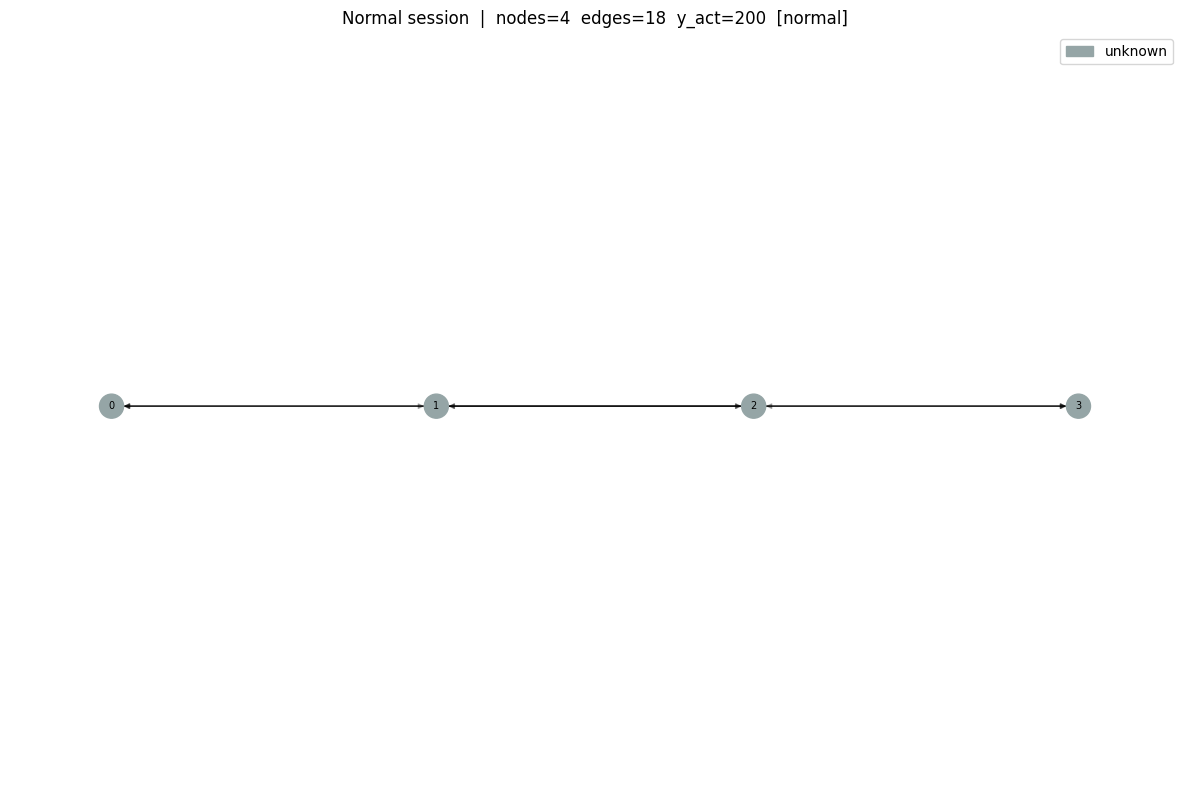

In [4]:
TYPE_COLORS = {
    "logon": "#e74c3c",
    "device": "#f39c12",
    "file": "#2ecc71",
    "email": "#3498db",
    "http": "#9b59b6",
    "unknown": "#95a5a6",
}

def plot_graph(data, title="", max_nodes=60):
    """Visualize a PyG Data graph with color-coded activity types."""
    n = data.x.shape[0]
    if n > max_nodes:
        print(f"Graph has {n} nodes, showing first {max_nodes}")
        return

    node_types = [detect_activity_type(data.x[i]) for i in range(n)]
    colors = [TYPE_COLORS[t] for t in node_types]

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    edges = data.edge_index.t().tolist()
    G.add_edges_from(edges)

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Use spring layout but seed with sequential positions for readability
    init_pos = {i: (i % 10, -(i // 10)) for i in range(n)}
    pos = nx.spring_layout(G, pos=init_pos, seed=42, k=2.0/np.sqrt(n))

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=300, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=8, ax=ax)

    patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLORS.items() if t in node_types]
    ax.legend(handles=patches, loc="upper right")

    label_str = "MALICIOUS" if data.y_label.item() == 1 else "normal"
    ax.set_title(f"{title}  |  nodes={n}  edges={len(edges)}  y_act={data.y_act.item()}  [{label_str}]")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Find a normal and a malicious graph to compare
normal_graph = next(g for g in graphs if g.y_label.item() == 0 and g.x.shape[0] <= 30)
mal_graph = next((g for g in graphs if g.y_label.item() == 1 and g.x.shape[0] <= 30), None)

plot_graph(normal_graph, title="Normal session")
if mal_graph:
    plot_graph(mal_graph, title="Malicious session")

## 4. Dataset statistics across the chunk

In [5]:
# Gather statistics
num_nodes_list = [g.x.shape[0] for g in graphs]
num_edges_list = [g.edge_index.shape[1] for g in graphs]
labels = [g.y_label.item() for g in graphs]
y_acts = [g.y_act.item() for g in graphs]

n_normal = labels.count(0)
n_malicious = labels.count(1)

print(f"Total graphs in chunk: {len(graphs)}")
print(f"  Normal:    {n_normal} ({100*n_normal/len(graphs):.1f}%)")
print(f"  Malicious: {n_malicious} ({100*n_malicious/len(graphs):.1f}%)")
print(f"\nNode count: min={min(num_nodes_list)}, max={max(num_nodes_list)}, "
      f"mean={np.mean(num_nodes_list):.1f}, median={np.median(num_nodes_list):.0f}")
print(f"Edge count: min={min(num_edges_list)}, max={max(num_edges_list)}, "
      f"mean={np.mean(num_edges_list):.1f}")
print(f"Unique activity codes (y_act): {len(set(y_acts))}")

Total graphs in chunk: 43998
  Normal:    43998 (100.0%)
  Malicious: 0 (0.0%)

Node count: min=4, max=49, mean=48.9, median=49
Edge count: min=18, max=2448, mean=1619.6
Unique activity codes (y_act): 39


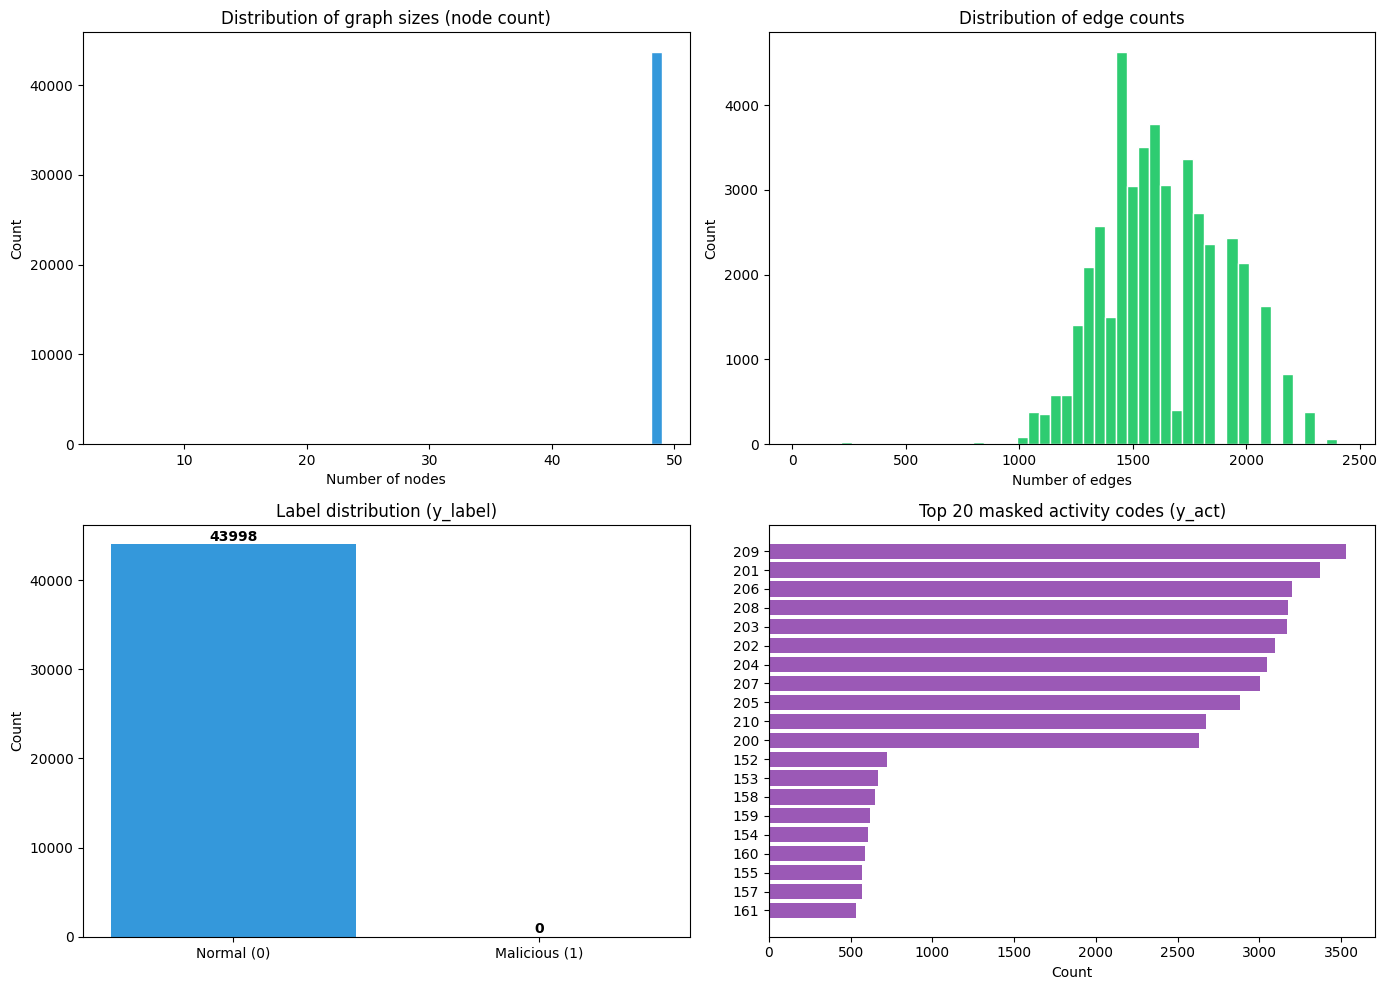

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Node count distribution
axes[0, 0].hist(num_nodes_list, bins=50, color="#3498db", edgecolor="white")
axes[0, 0].set_xlabel("Number of nodes")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of graph sizes (node count)")

# Edge count distribution
axes[0, 1].hist(num_edges_list, bins=50, color="#2ecc71", edgecolor="white")
axes[0, 1].set_xlabel("Number of edges")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of edge counts")

# Label distribution
axes[1, 0].bar(["Normal (0)", "Malicious (1)"], [n_normal, n_malicious],
               color=["#3498db", "#e74c3c"])
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Label distribution (y_label)")
for i, v in enumerate([n_normal, n_malicious]):
    axes[1, 0].text(i, v + len(graphs)*0.01, str(v), ha="center", fontweight="bold")

# Activity code distribution (top 20)
act_counts = Counter(y_acts)
top20 = act_counts.most_common(20)
codes, counts = zip(*top20)
axes[1, 1].barh(range(len(codes)), counts, color="#9b59b6")
axes[1, 1].set_yticks(range(len(codes)))
axes[1, 1].set_yticklabels([str(c) for c in codes])
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_title("Top 20 masked activity codes (y_act)")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Feature heatmap — what does `data.x` look like?

Each row = one node, each column = one of 54 feature dimensions.
You can clearly see the block-diagonal structure: each node has only one non-zero block.

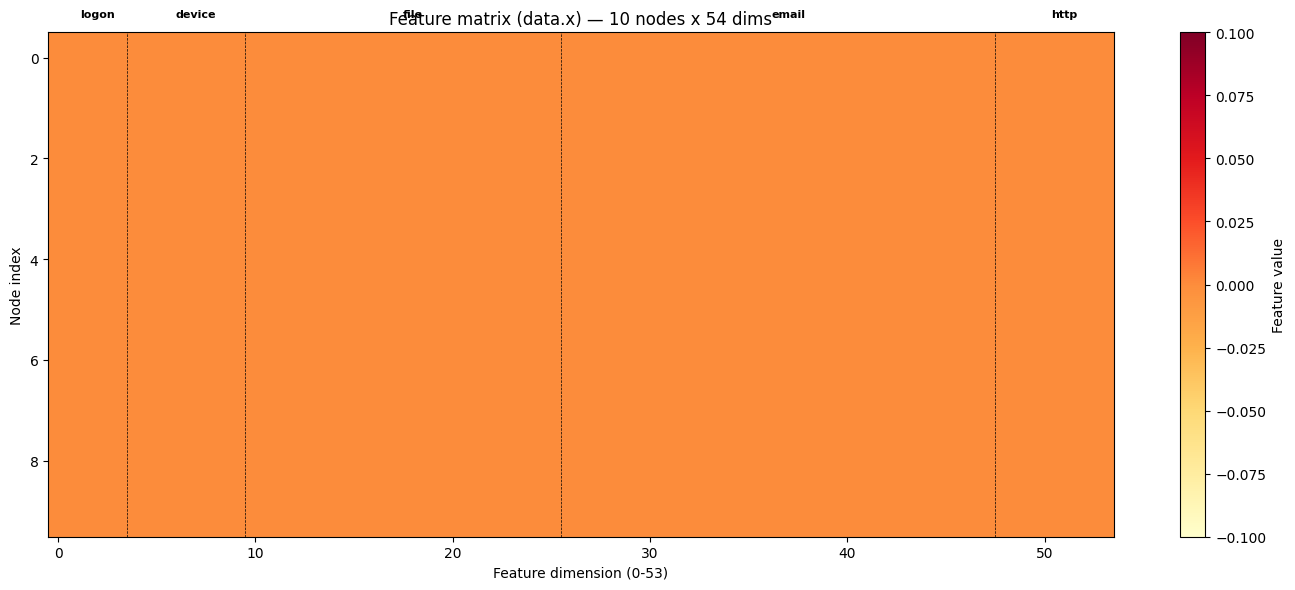

In [7]:
# Pick a small graph for clear visualization
small_g = next(g for g in graphs if 8 <= g.x.shape[0] <= 20)

fig, ax = plt.subplots(figsize=(14, 6))
feat = small_g.x.numpy()
im = ax.imshow(feat, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xlabel("Feature dimension (0-53)")
ax.set_ylabel("Node index")
ax.set_title(f"Feature matrix (data.x) — {small_g.x.shape[0]} nodes x 54 dims")
plt.colorbar(im, ax=ax, label="Feature value")

# Annotate blocks
block_boundaries = [0, 4, 10, 26, 48, 54]
block_names = ["logon", "device", "file", "email", "http"]
for i, (start, name) in enumerate(zip(block_boundaries[:-1], block_names)):
    mid = (start + block_boundaries[i+1]) / 2
    ax.text(mid, -0.8, name, ha="center", fontsize=8, fontweight="bold")
    if start > 0:
        ax.axvline(start - 0.5, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## 6. Adjacency matrix — explicit edges visualized

Shows the structure of `edge_index` as a dense matrix. You'll see:
- A **diagonal band** from sequential edges (temporal order)
- **Dense blocks** from activity-type cliques (nodes of the same type connected)

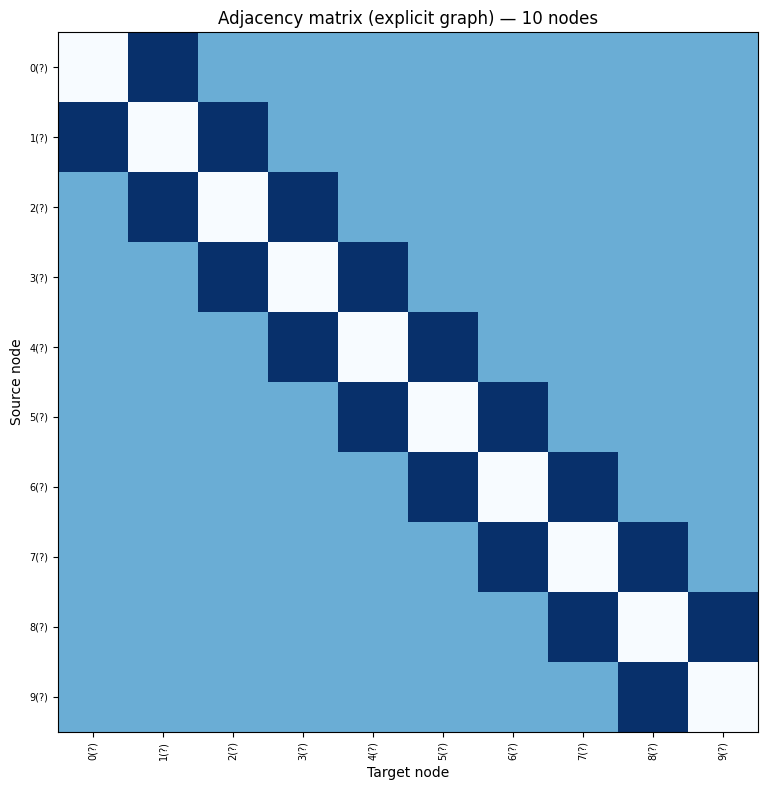

Legend: L=logon, D=device, F=file, E=email, H=http
You can see cliques: nodes of the same type are fully connected to each other.


In [8]:
from torch_geometric.utils import to_dense_adj

g = small_g
n = g.x.shape[0]
adj = to_dense_adj(g.edge_index, max_num_nodes=n).squeeze().numpy()
node_types = [detect_activity_type(g.x[i]) for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(adj, cmap="Blues", interpolation="nearest")
ax.set_xlabel("Target node")
ax.set_ylabel("Source node")
ax.set_title(f"Adjacency matrix (explicit graph) — {n} nodes")

# Label nodes with their activity type
type_abbrev = {"logon": "L", "device": "D", "file": "F", "email": "E", "http": "H", "unknown": "?"}
tick_labels = [f"{i}({type_abbrev[t]})" for i, t in enumerate(node_types)]
ax.set_xticks(range(n))
ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels(tick_labels, fontsize=7)

plt.tight_layout()
plt.show()

print("Legend: L=logon, D=device, F=file, E=email, H=http")
print(f"You can see cliques: nodes of the same type are fully connected to each other.")

## 7. How detection works (from the paper)

The model is trained with a **masked activity prediction** objective — NOT directly on the insider/normal labels.

### Training:
1. Model sees a session graph with one node removed
2. It predicts: "what activity was here?" → output is softmax over `num_classes` activity codes
3. **Custom loss**: for normal samples, maximize P(true activity). For malicious samples (`y_label=1`), set P(true activity)=0 and enforce uniform distribution over other classes

### Inference (insider detection):
1. Run model, get predicted probability for the true activity
2. If P(true activity) is **low** → model couldn't predict it → it's anomalous → likely insider threat
3. Threshold on this probability gives binary normal/malicious classification
4. Evaluate with AUC-ROC

### Why this works:
Normal activities are predictable (routine). Insider threat activities deviate from the pattern, so the model can't predict them confidently — **low confidence = anomaly signal**.